# Learning a 3-channel selector for lentils (Gumbel-Softmax + AdaCLIP)

Hyperspectral cameras measure many bands (61 for the Ultris XMR lentils dataset), but most
vision anomaly detectors expect a 3-channel image. **Which three bands should represent the
cube?** A fixed RGB triple washes out many foreign objects, a hand-picked CIR triple already
helps a lot - and the lentils whitepaper went one step further and *learned* the triple.

This tutorial reproduces that learning step end to end:

- a **ConcreteChannelMixer** (Gumbel-Softmax / Concrete relaxation) holds logits over the 61
  bands and learns a hard 61 -> 3 selection,
- it is trained by backpropagating an **IoU loss through a frozen AdaCLIP detector** on the
  original lentils datasplit (plus a small distinctness loss so the three picks repel),
- at the end the notebook **prints and visualizes the three winning bands** and runs the
  trained pipeline so you can see the anomaly maps it produces.

On the published full run the selector converged to **indices [14, 59, 57] = 542 / 902 /
886 nm** - the "custom selector" consumed by the champion Dinomaly pipeline in the sibling
[`lentils_dinomaly.ipynb`](lentils_dinomaly.ipynb) tutorial. Here you watch those bands
being found, rather than taking them as given.


In [1]:
# Colab bootstrap: install the packages when running in Colab; a no-op locally.
try:
    import cuvis_ai, cuvis_ai_adaclip, cuvis_ai_dataloader  # noqa: F401
except ImportError:
    %pip install -q cuvis-ai \
        "cuvis-ai-adaclip @ git+https://github.com/cubert-hyperspectral/cuvis-ai-adaclip.git@v0.3.1" \
        "cuvis-ai-dataloader[cu3s,coco] @ git+https://github.com/cubert-hyperspectral/cuvis-ai-dataloader.git@v0.6.0"


/mnt/data/anish/lentils_trainday/cuvis-ai/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%matplotlib inline
from __future__ import annotations

import csv
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from loguru import logger

from utils import iou, overlay_boundaries, to_uint8_rgb  # thin renderers shared by use_cases

logger.remove()
logger.add(sys.stderr, level="INFO")

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print(f"device: {device}")


device: cuda


## 1 - Dataset and objective

`cubert-gmbh/XMR_Industrial_Foreign_Object_Detection_Lentils`: 1136 frames of lentils on a
conveyor-belt background, captured with an Ultris XMR (61 bands, 430-910 nm, ~8 nm steps,
1000 x 1080 px). Foreign objects are annotated as semantic masks with 8 classes:

- `0` background / normal (lentils + belt)
- `1` stem_k, `2` stone, `3` alu_shard, `4` blue_paper, `5` white_paper, `6` fly, `7` rubber

Any non-zero class is treated as **anomalous** here. The official `splits.csv` datasplit is
train 808 (500 annotated + 308 normal), val 148, test 180; frames come in groups of four
lighting variants that always share a split, so nothing leaks between splits.

The selector below is trained **supervised** (it sees the train-split masks through the IoU
loss); the three bands it picks are then reused as a *fixed*, label-free front-end for
normal-only detectors such as Dinomaly.


## 2 - Knobs

One cell with everything you may want to change. The defaults are the **whitepaper recipe**
(full 808-frame train split, 20 epochs) - the setting that actually converges to the
published bands, and what the baked outputs below were produced with. It is a long run
(several hours on a single 24 GB GPU, ~17 GB peak). For a quick dry-run that executes end
to end in minutes, set `MAX_EPOCHS = 1` and `CONVERT_LIMIT = 24` (the band pick is then
meaningless - too few frames / one tau step).


In [3]:
DATA_DIR = Path("data")            # dataset download root (cwd-relative)
NPZ_DIR = Path("data_npz")         # converted per-frame NPZ + universe.csv + splits.json
MAX_EPOCHS = 20                    # whitepaper recipe; drives the Gumbel tau anneal. dry-run: 1
CONVERT_LIMIT = 0                  # 0 = all frames (full split). dry-run: e.g. 24 per split
BATCH_SIZE = 1
SEED = 42
RUN_VAL_EVAL = True                # validation pass after training
N_RESULT_FRAMES = 3                # annotated test frames to visualize at the end


## 3 - Get the data

Provisioning is the standard two lines: download the dataset once, then convert the split
manifest to per-frame NPZ plus the `universe.csv` / `splits.json` pair the data module
consumes. The conversion reads cu3s, so it needs the `cuvis-ai-dataloader[cu3s]` extra
(installed in the bootstrap cell). Re-runs resume: already-converted frames are skipped.


In [4]:
from cuvis_ai_core.data.public_datasets import PublicDatasets
from cuvis_ai_dataloader.data.npz_converter import convert_split_manifest

PublicDatasets.download_dataset("Industrial_FOD_Lentils", download_path=str(DATA_DIR), force=False)
raw_dir = DATA_DIR / "XMR_Industrial_Foreign_Object_Detection_Lentils"

universe_csv = NPZ_DIR / "universe.csv"
splits_json = NPZ_DIR / "splits.json"
result = convert_split_manifest(
    raw_dir / "splits.csv", raw_dir, NPZ_DIR,
    universe_csv=universe_csv, splits_json=splits_json,
    limit=CONVERT_LIMIT,
)
print(result)


2026-08-28 08:19:00.729 | INFO     | cuvis_ai_dataloader.data.npz_converter:convert_cu3s_file:162 - converted 2026_03_03_11-11-01.cu3s -> 2 frame(s) into data_npz (all reused, cu3s not opened)


2026-08-28 08:19:00.730 | INFO     | cuvis_ai_dataloader.data.npz_converter:convert_cu3s_file:162 - converted 2026_03_03_11-31-31.cu3s -> 17 frame(s) into data_npz (all reused, cu3s not opened)


2026-08-28 08:19:00.746 | INFO     | cuvis_ai_dataloader.data.npz_converter:convert_cu3s_file:162 - converted 2026_03_03_11-38-39.cu3s -> 81 frame(s) into data_npz (all reused, cu3s not opened)


2026-08-28 08:19:00.771 | INFO     | cuvis_ai_dataloader.data.npz_converter:convert_cu3s_file:162 - converted 2026_03_03_13-58-04_1.cu3s -> 96 frame(s) into data_npz (all reused, cu3s not opened)


2026-08-28 08:19:00.815 | INFO     | cuvis_ai_dataloader.data.npz_converter:convert_cu3s_file:162 - converted 2026_03_03_13-58-04_2.cu3s -> 136 frame(s) into data_npz (all reused, cu3s not opened)


...

2026-08-28 08:19:01.016 | INFO     | cuvis_ai_dataloader.data.npz_converter:convert_cu3s_file:162 - converted 2026_03_17_11-11-50.cu3s -> 80 frame(s) into data_npz (all reused, cu3s not opened)


2026-08-28 08:19:01.041 | INFO     | cuvis_ai_dataloader.data.npz_converter:convert_cu3s_file:162 - converted 2026_03_17_11-41-54.cu3s -> 80 frame(s) into data_npz (all reused, cu3s not opened)


2026-08-28 08:19:01.072 | INFO     | cuvis_ai_dataloader.data.npz_converter:convert_cu3s_file:162 - converted 2026_03_17_14-38-58.cu3s -> 100 frame(s) into data_npz (all reused, cu3s not opened)


2026-08-28 08:19:01.077 | INFO     | cuvis_ai_dataloader.data.npz_converter:convert_split_manifest:431 - convert_split_manifest: 1136 frame(s), 15 session(s) -> data_npz/universe.csv + data_npz/splits.json


SplitManifestOutputs(splits_json=PosixPath('data_npz/splits.json'), universe_csv=PosixPath('data_npz/universe.csv'))


In [5]:
# Per-channel wavelengths, read once from the first converted frame (all cubes share them).
# universe.csv stores `materialized_path` relative to its own directory, so resolve there.
with open(universe_csv, newline="", encoding="utf-8") as fh:
    universe_rows = list(csv.DictReader(fh))
first_npz = (universe_csv.parent / universe_rows[0]["materialized_path"]).resolve()
wavelengths = np.load(first_npz, allow_pickle=True)["wavelengths"].astype(float).ravel()
print(f"{len(universe_rows)} frames | {wavelengths.size} bands, "
      f"{wavelengths.min():.0f}-{wavelengths.max():.0f} nm")


1136 frames | 61 bands, 430-910 nm


### 3.1 - What the data looks like

One annotated frame, rendered three ways: a visible-light composite (650/550/450 nm), the
hand-picked CIR composite (860/670/560 nm), and the ground-truth mask on top of the visible
view (green = annotated foreign object). This is the problem in one figure: in the visible
composite the contaminants blend into the lentils; near-infrared bands separate them. The
selector's job is to find the three most useful bands automatically.


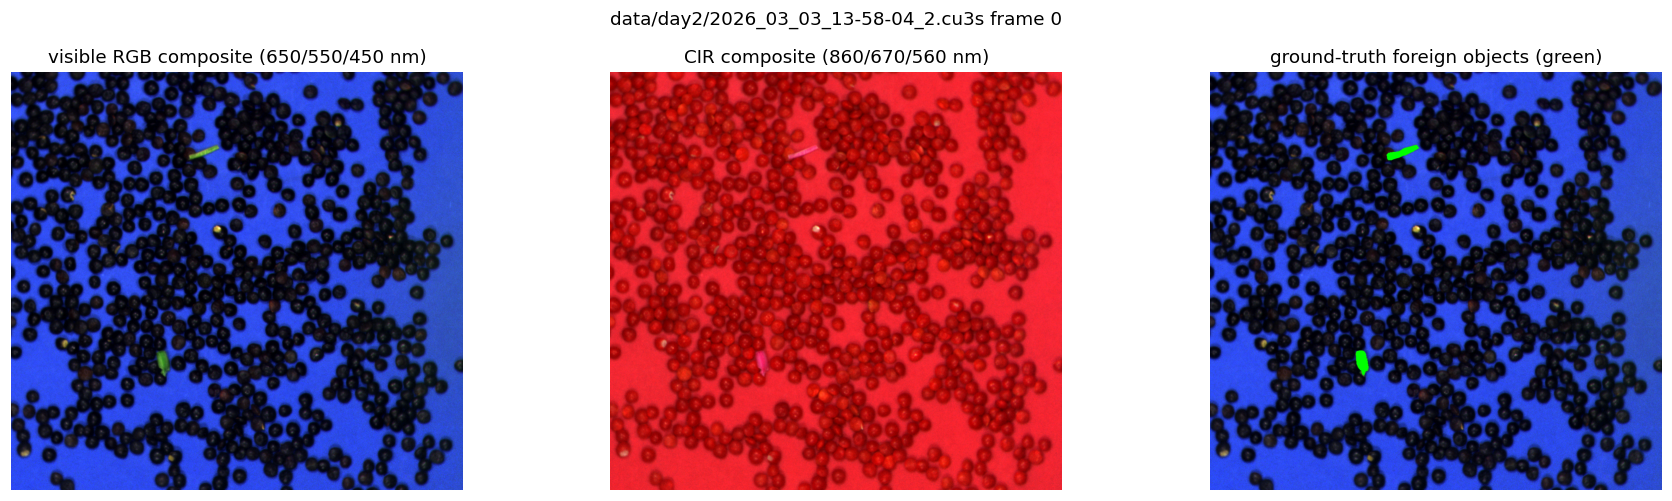

In [6]:
def band_index(nm: float) -> int:
    return int(np.argmin(np.abs(wavelengths - nm)))


def spectral_composite(cube: np.ndarray, targets_nm: tuple[float, float, float]) -> np.ndarray:
    img = np.stack([cube[:, :, band_index(nm)] for nm in targets_nm], axis=-1).astype(np.float32)
    lo, hi = np.percentile(img, 1), np.percentile(img, 99)
    return np.clip((img - lo) / max(hi - lo, 1e-6), 0, 1)


def load_frame(row: dict) -> tuple[np.ndarray, np.ndarray]:
    d = np.load((universe_csv.parent / row["materialized_path"]).resolve(), allow_pickle=True)
    return d["cube"].astype(np.float32), (np.asarray(d["mask"]).squeeze() > 0)


# splits.json knows which frames are test; pick annotated ones for illustration.
splits_doc = json.loads(splits_json.read_text(encoding="utf-8"))
test_keys = {(sel["source"], int(i)) for sel in splits_doc["test"] for i in sel["ids"]}
test_rows = [r for r in universe_rows if (r["source"], int(r["index"])) in test_keys]

sample_row = next(
    (r for r in test_rows if load_frame(r)[1].any()),
    next((r for r in universe_rows if load_frame(r)[1].any()), universe_rows[0]),
)
cube, gt = load_frame(sample_row)

rgb_vis = spectral_composite(cube, (650.0, 550.0, 450.0))
cir_vis = spectral_composite(cube, (860.0, 670.0, 560.0))
fig, ax = plt.subplots(1, 3, figsize=(16.5, 4.6), dpi=110)
ax[0].imshow(to_uint8_rgb(rgb_vis)); ax[0].set_title("visible RGB composite (650/550/450 nm)")
ax[1].imshow(to_uint8_rgb(cir_vis)); ax[1].set_title("CIR composite (860/670/560 nm)")
ax[2].imshow(overlay_boundaries(to_uint8_rgb(rgb_vis), np.zeros_like(gt), gt))
ax[2].set_title("ground-truth foreign objects (green)")
for a in ax:
    a.axis("off")
fig.suptitle(f"{sample_row['source']} frame {sample_row['index']}")
plt.tight_layout(); plt.show()


## 4 - The pipeline, node by node

```
AnomalyDataNode --cube--> MinMaxNormalizer --normalized--> ConcreteChannelMixer
      |                                                        |         |
      | mask                                             rgb (3ch)   selection_weights
      |                                                        v         v
      |                                              AdaCLIPDetector   DistinctnessLoss
      |                                                   | scores
      +----------------> IoULoss <------------------------+---> TwoStageBinaryDecider
      +--------> AnomalyDetectionMetrics <-- decisions ---------+
```

- **AnomalyDataNode** adapts each batch: `cube [B,H,W,61]`, binary `mask` (any class > 0 is
  a foreign object), `wavelengths`.
- **MinMaxNormalizer** learns global min/max over the train stream (statistical phase).
- **ConcreteChannelMixer** is the lesson: per output channel c it keeps logits over the 61
  input bands and samples `softmax((logits_c + Gumbel)/tau)` during training. `tau` anneals
  `10.0 -> 0.1` across `MAX_EPOCHS`, so the soft mixture hardens into a (near) one-hot pick;
  at val/test it uses the hard `argmax` bands (`use_hard_inference=True`).
- **AdaCLIPDetector** (frozen, `enable_gradients=True`) turns the selected 3-channel image
  into pixel anomaly scores; gradients flow *through* it into the selector logits only.
- **IoULoss** supervises those scores against the ground-truth masks; **DistinctnessLoss**
  (weight 0.1) repels the three channels from collapsing onto the same band.
- **TwoStageBinaryDecider + AnomalyDetectionMetrics** report IoU/precision/recall during
  val; **ScoreHeatmapVisualizer + TensorBoardMonitorNode** log score maps per epoch.


In [7]:
from cuvis_ai.node.anomaly_visualization import ScoreHeatmapVisualizer
from cuvis_ai.node.channel_mixer import ConcreteChannelMixer
from cuvis_ai.node.data import AnomalyDataNode
from cuvis_ai.node.deciders.two_stage_decider import TwoStageBinaryDecider
from cuvis_ai.node.losses import DistinctnessLoss, IoULoss
from cuvis_ai.node.metrics import AnomalyDetectionMetrics
from cuvis_ai.node.monitor import TensorBoardMonitorNode
from cuvis_ai.node.normalization import MinMaxNormalizer
from cuvis_ai_adaclip.node.adaclip_node import AdaCLIPDetector

anomaly_data = AnomalyDataNode(normal_class_ids=[0], name="anomaly_data")
normalizer = MinMaxNormalizer(eps=1e-6, use_running_stats=True, name="MinMaxNormalizer")
concrete_selector = ConcreteChannelMixer(
    input_channels=61,
    output_channels=3,
    tau_start=10.0,
    tau_end=0.1,
    max_epochs=MAX_EPOCHS,     # the tau anneal spans the whole training run
    use_hard_inference=True,
    name="concrete_selector",
)
adaclip = AdaCLIPDetector(
    weight_name="pretrained_all",
    backbone="ViT-L-14-336",
    prompt_text="",
    image_size=518,
    prompting_depth=4,
    prompting_length=5,
    gaussian_sigma=4.0,
    use_half_precision=False,
    enable_warmup=False,
    enable_gradients=True,     # frozen weights, but gradients must flow through to the selector
    use_torch_preprocess=True,
    name="adaclip",
)
iou_loss = IoULoss(weight=1.0, smooth=1e-6, normalize_method="minmax", name="iou_loss")
distinctness_loss = DistinctnessLoss(weight=0.1, name="distinctness_loss")
decider = TwoStageBinaryDecider(
    image_threshold=0.24, top_k_fraction=0.001, quantile=0.995, name="decider"
)
metrics_anomaly = AnomalyDetectionMetrics(name="metrics_anomaly")
score_heatmap = ScoreHeatmapVisualizer(normalize_scores=True, cmap="inferno", up_to=3, name="score_heatmap")
tensorboard = TensorBoardMonitorNode(
    output_dir="outputs/channel_selector/tensorboard",
    run_name="concrete_adaclip_lentils",
    name="TensorBoardMonitorNode",
)


2026-08-28 08:22:29.246 | WARNING  | cuvis_ai.node.monitor:_resolve_log_dir:141 - Run directory 'concrete_adaclip_lentils' already exists. Using 'concrete_adaclip_lentils_v8' instead.


2026-08-28 08:22:29.248 | INFO     | cuvis_ai.node.monitor:__init__:117 - TensorBoard writer initialized: outputs/channel_selector/tensorboard/concrete_adaclip_lentils_v8


2026-08-28 08:22:29.248 | INFO     | cuvis_ai.node.monitor:__init__:118 - To view visualizations, run: uv run tensorboard --logdir=outputs/channel_selector/tensorboard


In [8]:
from cuvis_ai_core.pipeline.pipeline import CuvisPipeline

pipeline = CuvisPipeline("concrete_adaclip_lentils")

pipeline.connect(anomaly_data.outputs.cube, normalizer.inputs.data)
pipeline.connect(normalizer.outputs.normalized, concrete_selector.inputs.data)
pipeline.connect(concrete_selector.outputs.rgb, adaclip.inputs.rgb_image)

pipeline.connect(adaclip.outputs.scores, iou_loss.inputs.predictions)
pipeline.connect(anomaly_data.outputs.mask, iou_loss.inputs.targets)
pipeline.connect(concrete_selector.outputs.selection_weights, distinctness_loss.inputs.selection_weights)

pipeline.connect(adaclip.outputs.scores, decider.inputs.logits)
pipeline.connect(adaclip.outputs.scores, metrics_anomaly.inputs.logits)
pipeline.connect(anomaly_data.outputs.mask, metrics_anomaly.inputs.targets)
pipeline.connect(decider.outputs.decisions, metrics_anomaly.inputs.decisions)

pipeline.connect(adaclip.outputs.scores, score_heatmap.inputs.scores)
pipeline.connect(metrics_anomaly.outputs.metrics, tensorboard.inputs.metrics)
pipeline.connect(score_heatmap.outputs.artifacts, tensorboard.inputs.artifacts)

pipeline.to(device)
pipeline


concrete_adaclip_lentils:
AnomalyDataNode(
  (_binary_mapper): BinaryAnomalyLabelMapper()
)
MinMaxNormalizer()
ConcreteChannelMixer()
AdaCLIPDetector()
IoULoss()
DistinctnessLoss()
TwoStageBinaryDecider()
AnomalyDetectionMetrics(
  (precision_metric): BinaryPrecision()
  (recall_metric): BinaryRecall()
  (f1_metric): BinaryF1Score()
  (iou_metric): BinaryJaccardIndex()
  (average_precision_metric): BinaryAveragePrecision()
)
ScoreHeatmapVisualizer()
TensorBoardMonitorNode()
Use `pipeline.visualize()` for Graphviz/Mermaid output.

## 5 - Train: statistical phase, then gradient phase

`npz_multi` serves the converted frames through the frozen `splits.json` selectors, so the
run uses exactly the original datasplit. Training is the usual two-phase Cuvis.AI story:
the **StatisticalTrainer** fits data-derived state (the normalizer bounds) from the train
stream, then the **GradientTrainer** optimizes - after unfreezing **only** the selector.
The recipe mirrors the original trainrun: AdamW lr 1e-3 / weight-decay 0.01,
reduce-on-plateau on `metrics_anomaly/iou`, gradient clip 1.0.


In [9]:
import pytorch_lightning as pl

from cuvis_ai_core.training import GradientTrainer, StatisticalTrainer
from cuvis_ai_core.training.config import TrainingConfig
from cuvis_ai_dataloader.data.datamodule_npz_multi import MultiNpzDataModule
from cuvis_ai_schemas.training.data import DataSplitConfig

pl.seed_everything(SEED, workers=True)

datamodule = MultiNpzDataModule(
    splits=DataSplitConfig(splits_path=str(splits_json)),
    universe_csv=str(universe_csv),
    batch_size=BATCH_SIZE,
    num_workers=0,
)

StatisticalTrainer(pipeline=pipeline, datamodule=datamodule).fit()

pipeline.unfreeze_nodes_by_name(["concrete_selector"])  # everything else stays frozen

training_config = TrainingConfig.model_validate({
    "seed": SEED,
    "max_epochs": MAX_EPOCHS,
    "accelerator": "auto",
    "devices": 1,
    "default_root_dir": "outputs/channel_selector",
    "precision": "32-true",
    "enable_progress_bar": False,   # static tutorial: keep the baked output readable
    "log_every_n_steps": 200,
    "check_val_every_n_epoch": 1,
    "gradient_clip_val": 1.0,
    "optimizer": {"name": "adamw", "lr": 1e-3, "weight_decay": 0.01, "betas": [0.9, 0.999]},
    "scheduler": {
        "name": "reduce_on_plateau", "monitor": "metrics_anomaly/iou", "mode": "max",
        "factor": 0.5, "patience": 5, "min_lr": 1e-6,
    },
})
trainer = GradientTrainer(
    pipeline=pipeline,
    datamodule=datamodule,
    loss_nodes=[iou_loss, distinctness_loss],
    metric_nodes=[metrics_anomaly],
    training_config=training_config,
)
trainer.fit()


Seed set to 42


2026-08-28 08:22:29.504 | INFO     | cuvis_ai_core.training.trainers:fit:559 - Training 1 statistical nodes...


2026-08-28 08:22:29.505 | INFO     | cuvis_ai_core.training.trainers:fit:567 -   Training MinMaxNormalizer...


Seed set to 42


2026-08-28 08:34:36.847 | INFO     | cuvis_ai_core.training.trainers:fit:148 - ============================================================


...

2026-08-28 16:28:19.042 | INFO     | cuvis_ai_adaclip.adaclip_upstream:predict:291 - [cuvis_ai_adaclip] AdaCLIP inference time: 0.140s (139.9ms), batch_size=1, per_image=139.9ms


2026-08-28 16:28:20.218 | INFO     | cuvis_ai_adaclip.adaclip_upstream:predict:291 - [cuvis_ai_adaclip] AdaCLIP inference time: 0.137s (137.4ms), batch_size=1, per_image=137.4ms


`Trainer.fit` stopped: `max_epochs=20` reached.


┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ pipeline_modules │ ModuleList │    183 │ train │     0 │
└───┴──────────────────┴────────────┴────────┴───────┴───────┘

Trainable params: 183                                                                                              
Non-trainable params: 0                                                                                            
Total params: 183                                                                                                  
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 17                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

## 6 - The three selected channels

The payoff: the selector's logits, hardened by the tau anneal, name three bands. On the
published whitepaper run they converged to **indices [14, 59, 57] = 542 / 902 / 886 nm** -
one green band plus two near-infrared bands, which became the fixed "custom selector" of
the champion Dinomaly pipeline.


In [10]:
bands = concrete_selector.get_selected_bands().tolist()
band_nm = [float(wavelengths[b]) for b in bands]

print("Selected band indices (channel 1, 2, 3):", bands)
print("Selected wavelengths [nm]:            ", [round(w, 1) for w in band_nm])
print()
print("Hint: reuse these three wavelengths as a fixed selector in any 3-channel pipeline,")
print("e.g. for the Dinomaly foreign-object detector:")
print()
print("    FixedWavelengthSelector(")
print(f"        target_wavelengths={[round(w, 1) for w in band_nm]},")
print("        normalize_output=True, apply_gamma=True,")
print("    )")
print()
print("Published full-split run: indices [14, 59, 57] = 542 / 902 / 886 nm. The selection")
print("depends on the data, the epochs (tau anneal), and the seed - a smoke run or another")
print("seed can land on neighbouring bands; spectrally close picks are equally usable.")


Selected band indices (channel 1, 2, 3): [40, 59, 58]
Selected wavelengths [nm]:             [750.0, 902.0, 894.0]

Hint: reuse these three wavelengths as a fixed selector in any 3-channel pipeline,
e.g. for the Dinomaly foreign-object detector:

    FixedWavelengthSelector(
        target_wavelengths=[750.0, 902.0, 894.0],
        normalize_output=True, apply_gamma=True,
    )

Published full-split run: indices [14, 59, 57] = 542 / 902 / 886 nm. The selection
depends on the data, the epochs (tau anneal), and the seed - a smoke run or another
seed can land on neighbouring bands; spectrally close picks are equally usable.


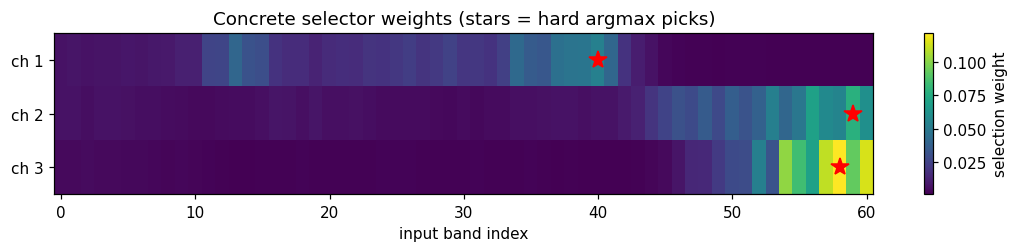

In [11]:
# The full selection-weight matrix: rows = output channels, columns = the 61 input bands.
weights = concrete_selector.get_selection_weights(deterministic=True).detach().cpu().numpy()

fig, ax = plt.subplots(figsize=(10, 2.4), dpi=110)
im = ax.imshow(weights, aspect="auto", cmap="viridis")
ax.set_yticks(range(weights.shape[0]), [f"ch {i + 1}" for i in range(weights.shape[0])])
ax.set_xlabel("input band index")
for row, b in enumerate(bands):
    ax.plot(b, row, "r*", markersize=12)
fig.colorbar(im, ax=ax, label="selection weight")
ax.set_title("Concrete selector weights (stars = hard argmax picks)")
plt.tight_layout(); plt.show()


### 6.1 - What the detector actually sees

The same sample frame from section 3.1, rendered as the plain visible composite next to the
**learned 3-band composite**. The selected near-infrared bands lift the foreign objects out
of the lentil texture - this contrast is what the IoU loss optimized for.


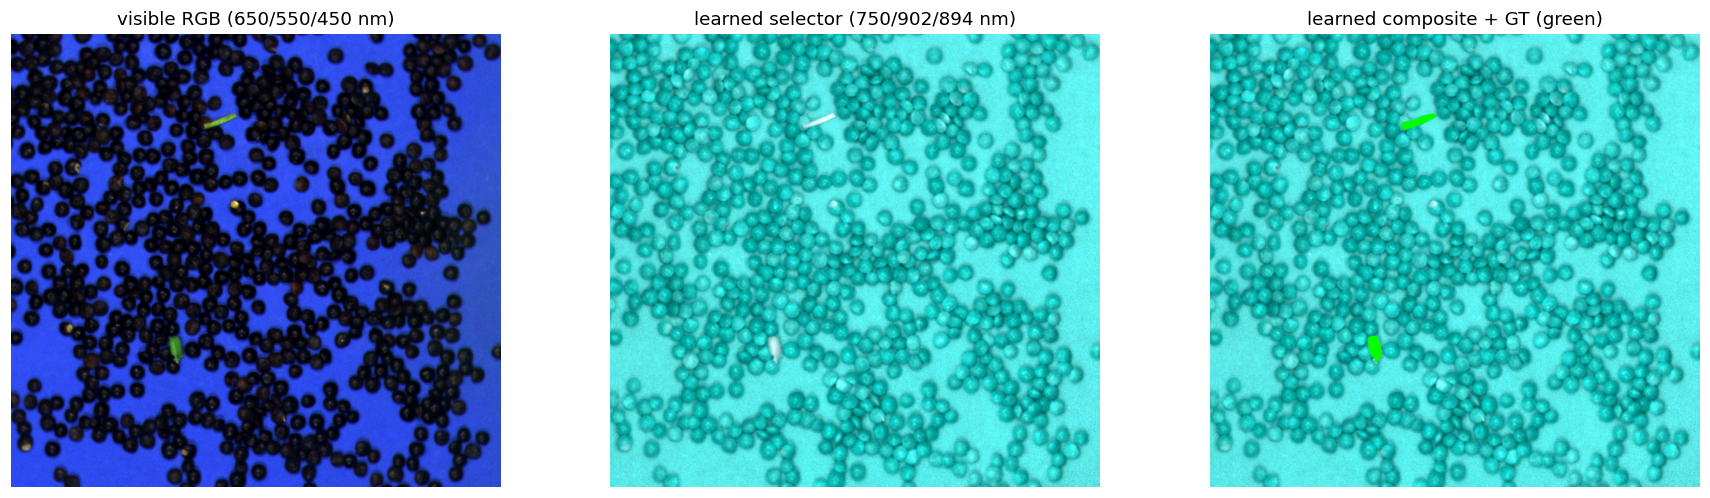

In [12]:
selected_vis = spectral_composite(cube, tuple(band_nm))
fig, ax = plt.subplots(1, 3, figsize=(16.5, 4.6), dpi=110)
ax[0].imshow(to_uint8_rgb(rgb_vis)); ax[0].set_title("visible RGB (650/550/450 nm)")
ax[1].imshow(to_uint8_rgb(selected_vis))
ax[1].set_title(f"learned selector ({'/'.join(f'{w:.0f}' for w in band_nm)} nm)")
ax[2].imshow(overlay_boundaries(to_uint8_rgb(selected_vis), np.zeros_like(gt), gt))
ax[2].set_title("learned composite + GT (green)")
for a in ax:
    a.axis("off")
plt.tight_layout(); plt.show()


## 7 - Run the trained pipeline: heatmaps and predicted masks

Now the whole pipeline runs as it would at inference (hard band selection active) on a few
test frames - the ones below contain annotated foreign objects, plus one normal frame. For
each frame we show:

- the selector's 3-channel output (the detector input),
- the dense AdaCLIP anomaly heatmap,
- the thresholded prediction against the ground truth.

Overlay colours: **green** = GT object pixels, **red** = predicted pixels, **yellow** =
overlap. The `TwoStageBinaryDecider` first gates each frame on its image-level score
(threshold 0.24, tuned for a demo), so a clean frame yields an empty mask instead of the
top-quantile speckle.


In [13]:
from cuvis_ai_schemas.enums import ExecutionStage
from cuvis_ai_schemas.execution import Context
from cuvis_ai_schemas.training.data import DataSplitConfig as _DSC

# A handful of test frames: N_RESULT_FRAMES annotated + 1 normal, selected via their masks.
anom_rows, normal_rows = [], []
for r in test_rows:
    (anom_rows if load_frame(r)[1].any() else normal_rows).append(r)
    if len(anom_rows) >= N_RESULT_FRAMES and normal_rows:
        break
result_rows = anom_rows[:N_RESULT_FRAMES] + normal_rows[:1]

by_source: dict[str, list[int]] = {}
for r in result_rows:
    by_source.setdefault(r["source"], []).append(int(r["index"]))
predict_splits = _DSC.model_validate({
    "train": [], "val": [], "test": [],
    "predict": [{"kind": "file_indices", "source": s, "ids": sorted(ids)}
                for s, ids in sorted(by_source.items())],
})
predict_dm = MultiNpzDataModule(
    splits=predict_splits, universe_csv=str(universe_csv), batch_size=1, num_workers=0
)

# Inference is a plain forward pass: the pipeline is a torch module, so module and batch
# must share a device (same pattern the sibling lentils_dinomaly utils use). Lightning
# hands the module back on CPU after fit(), so move it explicitly first.
pipeline.to(device)
predict_dm.setup(stage="predict")
KEEP_PORTS = {"rgb", "scores", "decisions", "mask"}
outputs = []
with torch.no_grad():
    for batch_idx, batch in enumerate(predict_dm.predict_dataloader()):
        batch = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in batch.items()}
        out = pipeline.forward(
            batch=batch, context=Context(stage=ExecutionStage.INFERENCE, batch_idx=batch_idx)
        )
        outputs.append({
            key: value.detach().cpu()
            for key, value in out.items()
            if key[1] in KEEP_PORTS and torch.is_tensor(value)
        })
print(f"ran {len(outputs)} frames")


2026-08-28 16:28:57.723 | INFO     | cuvis_ai_adaclip.adaclip_upstream:predict:291 - [cuvis_ai_adaclip] AdaCLIP inference time: 0.134s (133.9ms), batch_size=1, per_image=133.9ms


2026-08-28 16:28:58.896 | INFO     | cuvis_ai_adaclip.adaclip_upstream:predict:291 - [cuvis_ai_adaclip] AdaCLIP inference time: 0.141s (141.4ms), batch_size=1, per_image=141.4ms


2026-08-28 16:29:00.021 | INFO     | cuvis_ai_adaclip.adaclip_upstream:predict:291 - [cuvis_ai_adaclip] AdaCLIP inference time: 0.143s (143.1ms), batch_size=1, per_image=143.1ms


2026-08-28 16:29:01.168 | INFO     | cuvis_ai_adaclip.adaclip_upstream:predict:291 - [cuvis_ai_adaclip] AdaCLIP inference time: 0.139s (138.9ms), batch_size=1, per_image=138.9ms


ran 4 frames


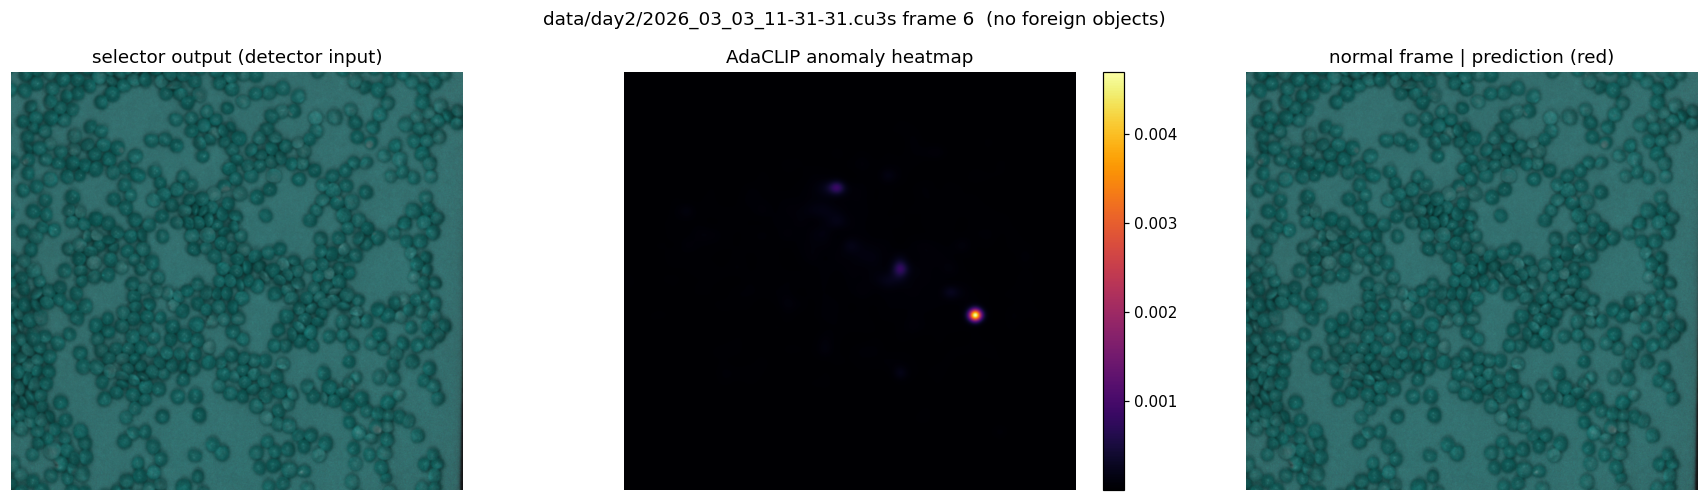

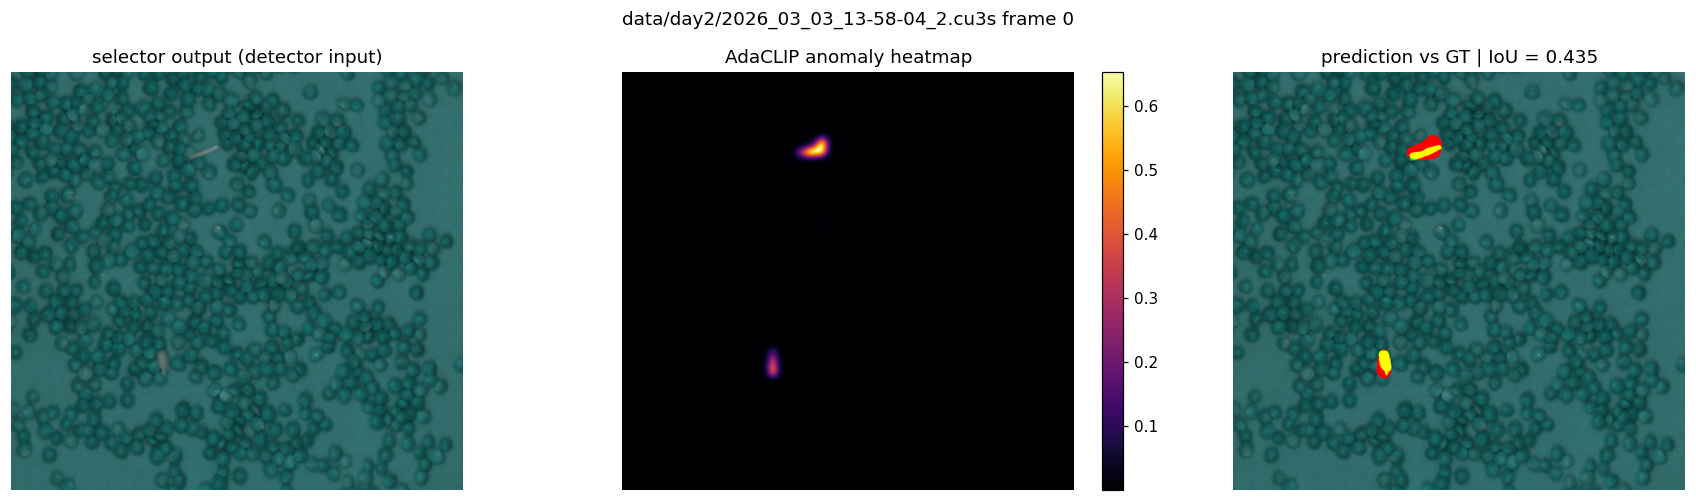

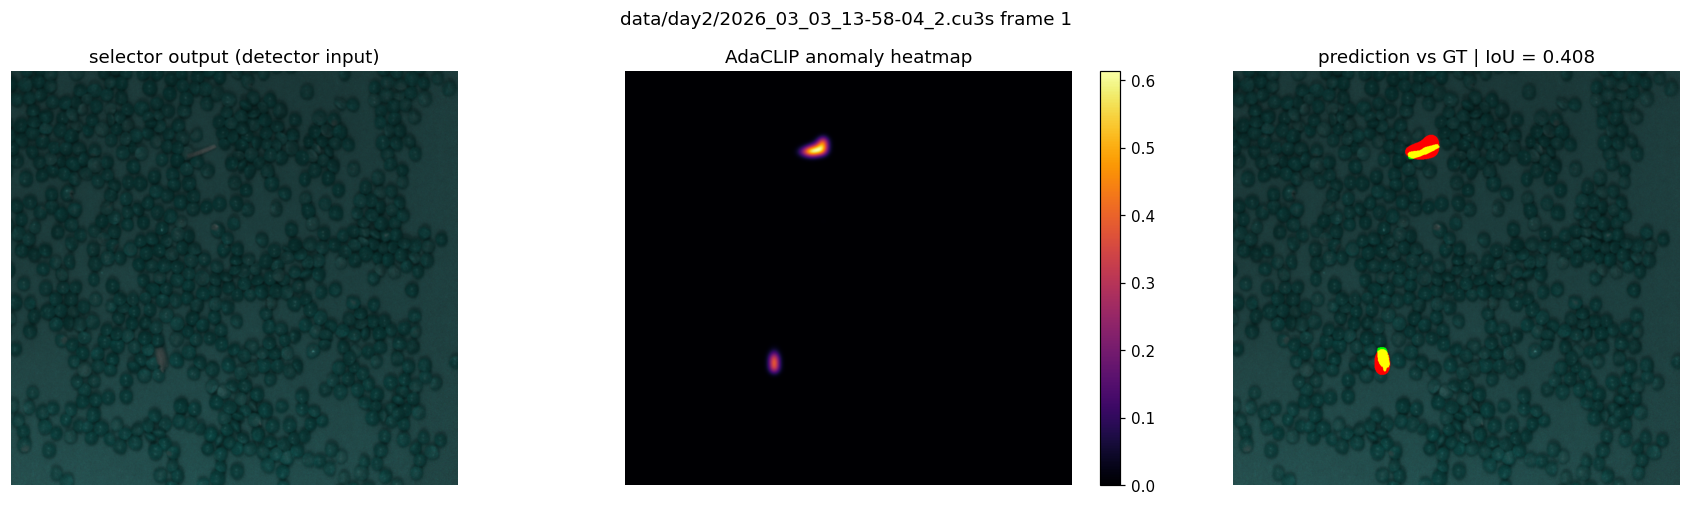

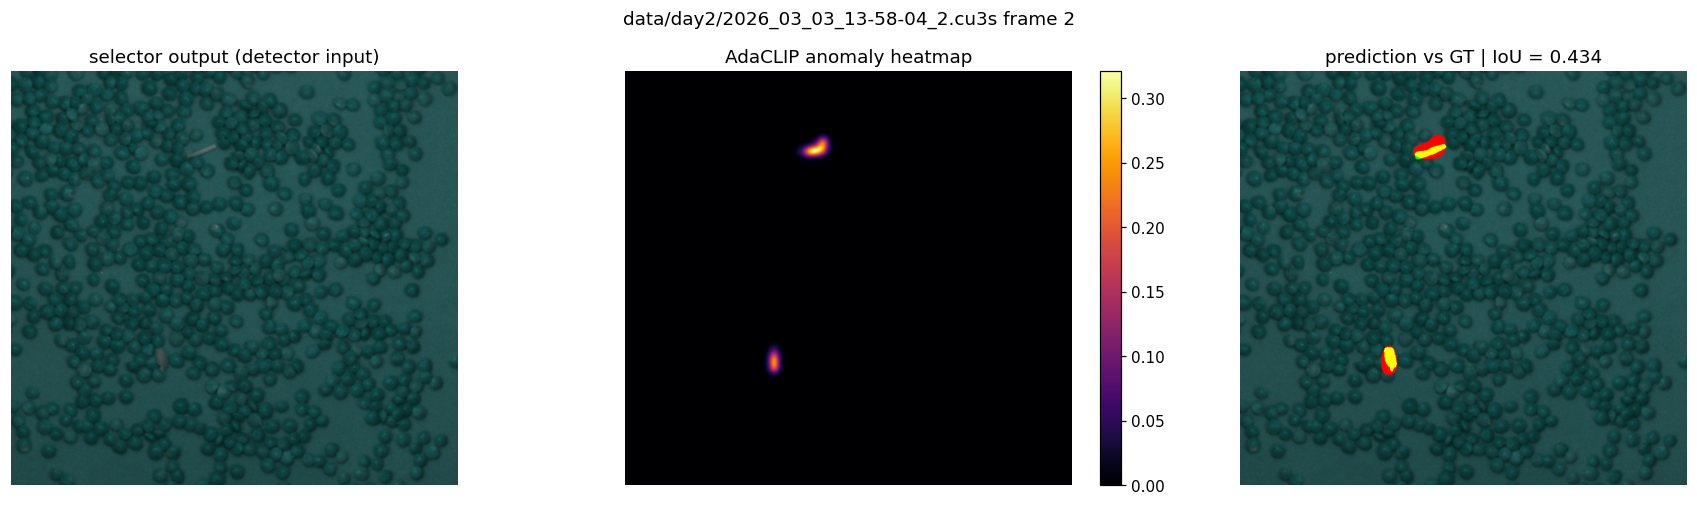

In [14]:
ordered = [(s, i) for s, ids in sorted(by_source.items()) for i in sorted(ids)]
for k, out in enumerate(outputs):
    ports = {port: v.squeeze().numpy() for (node, port), v in out.items()}
    rgb_in = ports["rgb"]
    scores = ports["scores"]
    pred = ports.get("decisions", np.zeros_like(scores)).astype(bool)
    gt_k = ports.get("mask", np.zeros_like(scores)).astype(bool)
    src, idx = ordered[k]

    fig, ax = plt.subplots(1, 3, figsize=(16.5, 4.6), dpi=110)
    ax[0].imshow(to_uint8_rgb(rgb_in)); ax[0].set_title("selector output (detector input)")
    hm = ax[1].imshow(scores, cmap="inferno"); ax[1].set_title("AdaCLIP anomaly heatmap")
    fig.colorbar(hm, ax=ax[1], fraction=0.046)
    ax[2].imshow(overlay_boundaries(to_uint8_rgb(rgb_in), pred, gt_k))
    ax[2].set_title(f"prediction vs GT | IoU = {iou(pred, gt_k):.3f}"
                    if gt_k.any() else "normal frame | prediction (red)")
    for a in ax:
        a.axis("off")
    fig.suptitle(f"{src} frame {idx}" + ("" if gt_k.any() else "  (no foreign objects)"))
    plt.tight_layout(); plt.show()


## 8 - Validation metrics

The metric node already ran during training; a standalone validation pass prints the
val-split metrics for the trained selector (with hard band selection active).


In [15]:
if RUN_VAL_EVAL:
    val_metrics = trainer.validate()
    print(val_metrics)


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


/mnt/data/anish/lentils_trainday/cuvis-ai/.venv/lib/python3.11/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/mnt/data/anish/lentils_trainday/cuvis-ai/.venv/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.


2026-08-28 16:29:03.536 | INFO     | cuvis_ai_adaclip.adaclip_upstream:predict:291 - [cuvis_ai_adaclip] AdaCLIP inference time: 0.138s (138.2ms), batch_size=1, per_image=138.2ms


2026-08-28 16:29:04.713 | INFO     | cuvis_ai_adaclip.adaclip_upstream:predict:291 - [cuvis_ai_adaclip] AdaCLIP inference time: 0.140s (140.2ms), batch_size=1, per_image=140.2ms


2026-08-28 16:29:05.917 | INFO     | cuvis_ai_adaclip.adaclip_upstream:predict:291 - [cuvis_ai_adaclip] AdaCLIP inference time: 0.141s (141.3ms), batch_size=1, per_image=141.3ms


...

2026-08-28 16:31:51.480 | INFO     | cuvis_ai_adaclip.adaclip_upstream:predict:291 - [cuvis_ai_adaclip] AdaCLIP inference time: 0.140s (139.5ms), batch_size=1, per_image=139.5ms


2026-08-28 16:31:52.646 | INFO     | cuvis_ai_adaclip.adaclip_upstream:predict:291 - [cuvis_ai_adaclip] AdaCLIP inference time: 0.143s (143.0ms), batch_size=1, per_image=143.0ms


2026-08-28 16:31:53.772 | INFO     | cuvis_ai_adaclip.adaclip_upstream:predict:291 - [cuvis_ai_adaclip] AdaCLIP inference time: 0.142s (141.7ms), batch_size=1, per_image=141.7ms


[{'val/iou_loss': 0.8638729453086853, 'val/distinctness_loss': nan, 'val_loss': nan, 'metrics_anomaly/precision': 0.09331481158733368, 'metrics_anomaly/recall': 0.32232406735420227, 'metrics_anomaly/f1_score': 0.13147097826004028, 'metrics_anomaly/iou': 0.08285877853631973, 'metrics_anomaly/average_precision': 0.3764112591743469}]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃          Validate metric          ┃           DataLoader 0            ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ metrics_anomaly/average_precision │        0.3764112591743469         │
│     metrics_anomaly/f1_score      │        0.13147097826004028        │
│        metrics_anomaly/iou        │        0.08285877853631973        │
│     metrics_anomaly/precision     │        0.09331481158733368        │
│      metrics_anomaly/recall       │        0.32232406735420227        │
│       val/distinctness_loss       │                nan                │
│           val/iou_loss            │        0.8638729453086853         │
│             val_loss              │                nan                │
└───────────────────────────────────┴───────────────────────────────────┘

## 9 - Where to go from here

- Drop the printed wavelengths into a `FixedWavelengthSelector` and train a normal-only
  **Dinomaly** pipeline on them - that exact hand-off is the sibling
  [`lentils_dinomaly.ipynb`](lentils_dinomaly.ipynb) tutorial, whose "custom selector"
  method uses the published bands from this recipe.
- A fixed 3-band representation is also a deployment story: a 3-filter multispectral
  sensor could replace the full hyperspectral acquisition for this task.
- Reproduction notes: the whitepaper-scale run is `MAX_EPOCHS = 20`, `CONVERT_LIMIT = 0`
  (full 808-frame train split) - several hours on one 24 GB GPU, ~17 GB peak VRAM. Band
  picks are seed-sensitive within spectrally similar neighbours (this baked run landed on
  750/902/894 nm, sharing the two NIR bands with the published 542/902/886 nm); the
  demo-scale dataset converges to different bands than the full split, so use the full
  split when you want the published triple. The cu3s -> npz conversion is the slow part
  (~26 s/frame); it resumes, so converted frames are never re-read.
